# Loading Libraries

In [ ]:
!pip install unsloth
!pip install --no-deps transformers==4.55.0
!pip install --no-deps causal-conv1d==1.5.0.post8

In [ ]:
!pip install transformers -U

# Loading Model and Adapters

In [ ]:
from unsloth import FastModel
import torch
from datasets import Dataset
import pandas as pd
import ast
import json

fourbit_models = [
    "unsloth/LFM2-1.2B-unsloth-bnb-4bit",
    "unsloth/LFM2-700M-unsloth-bnb-4bit",
    "unsloth/LFM2-350M-unsloth-bnb-4bit",
    "unsloth/LFM2-1.2B",
    "unsloth/LFM2-700M",
    "unsloth/LFM2-350M",
]

model, tokenizer = FastModel.from_pretrained(
    model_name = "unsloth/LFM2-1.2B",
    dtype = None,
    max_seq_length = 2048,
    load_in_4bit = False,
    full_finetuning = False,
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2025.11.4: Fast Lfm2 patching. Transformers: 4.57.3.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.33.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


model.safetensors:   0%|          | 0.00/2.34G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/434 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/209 [00:00<?, ?B/s]

In [ ]:
model = FastModel.get_peft_model(
    model,
    finetune_vision_layers = False,
    finetune_language_layers = True,
    finetune_attention_modules = True,
    finetune_mlp_modules = True,
    r = 16,
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
)

Unsloth: Making `model.base_model.model.model` require gradients


# Loading and Formatting Training Dataset

In [ ]:
df = pd.read_csv('food.csv')

chat_data = []
for _, row in df.iterrows():
    try:
        ingredients = ast.literal_eval(row['ingredients'])
        directions = ast.literal_eval(row['directions'])
    except:
        ingredients = row['ingredients']
        directions = row['directions']

    conversation = [
        {
            "role": "user",
            "content": f"Output the ingredients and directions for making {row['title']} in JSON format with two keys: 'ingredients' and 'directions'."
        },
        {
            "role": "assistant",
            "content": f'{{"ingredients": {ingredients}, "directions": {directions}}}'
        }
    ]
    chat_data.append({"conversations": conversation})

dataset = Dataset.from_list(chat_data)

def formatting_prompts_func(examples):
    texts = tokenizer.apply_chat_template(
        examples["conversations"],
        tokenize = False,
        add_generation_prompt = False,
    )
    return { "text" : [x.removeprefix(tokenizer.bos_token) for x in texts] }

dataset = dataset.map(formatting_prompts_func, batched = True)


Map:   0%|          | 0/7127 [00:00<?, ? examples/s]

# Initialzing Trainer

In [ ]:
from trl import SFTTrainer, SFTConfig
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    eval_dataset = None,
    args = SFTConfig(
        dataset_text_field = "text",
        per_device_train_batch_size = 8,
        gradient_accumulation_steps = 2,
        warmup_steps = 100,
        num_train_epochs = 3,
        learning_rate = 2e-4,
        logging_steps = 50,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        report_to = "none",
        save_steps = 3000,
    ),
)

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/7127 [00:00<?, ? examples/s]

In [ ]:
from unsloth.chat_templates import train_on_responses_only
trainer = train_on_responses_only(
    trainer,
    instruction_part = "<|im_start|>user\n",
    response_part = "<|im_start|>assistant\n",
)

Map (num_proc=6):   0%|          | 0/7127 [00:00<?, ? examples/s]

# Starting Training

In [ ]:
trainer_stats = trainer.train()

trainer.save_model("lfm2_finetuned")

from google.colab import files
import shutil

shutil.make_archive("lfm2_finetuned", 'zip', "lfm2_finetuned")
files.download("lfm2_finetuned.zip")

The model is already on multiple devices. Skipping the move to device specified in `args`.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 7,127 | Num Epochs = 3 | Total steps = 1,338
O^O/ \_/ \    Batch size per device = 8 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (8 x 2 x 1) = 16
 "-____-"     Trainable parameters = 9,142,272 of 1,179,482,880 (0.78% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
50,2.040600
100,1.773400
150,1.718100
200,1.666200
250,1.656600
300,1.629800
350,1.633100
400,1.624700
450,1.627500
500,1.560600


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Plotting Training Losses

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.interpolate import make_interp_spline

steps = [50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600, 650, 700, 750, 800, 850, 900, 950, 1000, 1050, 1100, 1150, 1200, 1250, 1300]
loss = [2.040600, 1.773400, 1.718100, 1.666200, 1.656600, 1.629800, 1.633100, 1.624700, 1.627500, 1.560600, 1.580300, 1.554700, 1.546500, 1.538300, 1.534300, 1.533900, 1.541200, 1.523900, 1.459100, 1.476000, 1.503800, 1.493500, 1.457900, 1.480800, 1.457900, 1.461800]

sns.set_style("whitegrid")

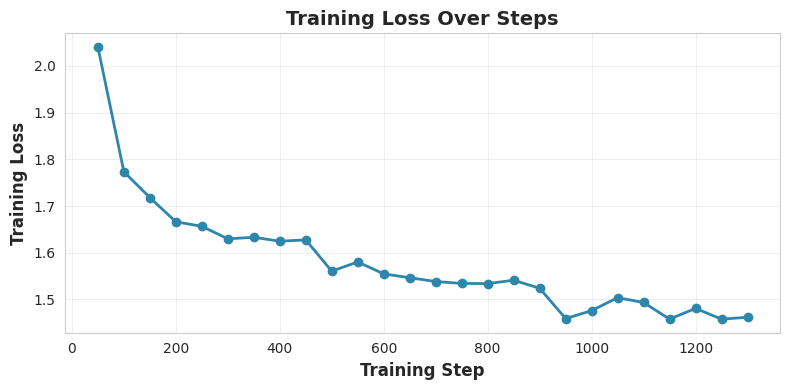

In [4]:
plt.figure(figsize=(8, 4))
plt.plot(steps, loss, marker='o', linewidth=2, markersize=6, color='#2E86AB')
plt.xlabel('Training Step', fontsize=12, fontweight='bold')
plt.ylabel('Training Loss', fontsize=12, fontweight='bold')
plt.title('Training Loss Over Steps', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

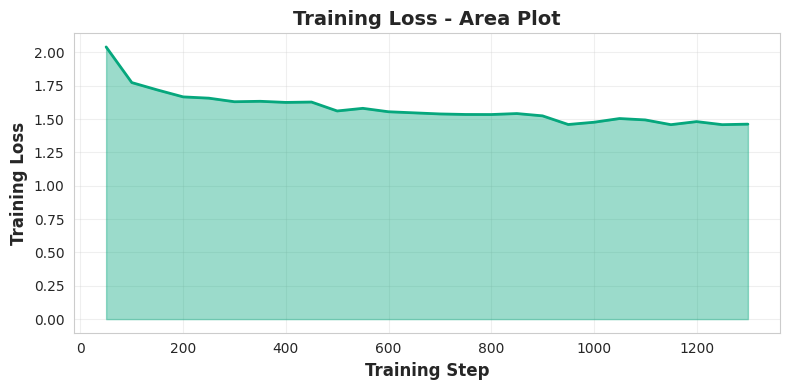

In [6]:
plt.figure(figsize=(8, 4))
plt.fill_between(steps, loss, alpha=0.4, color='#06A77D')
plt.plot(steps, loss, linewidth=2, color='#06A77D')
plt.xlabel('Training Step', fontsize=12, fontweight='bold')
plt.ylabel('Training Loss', fontsize=12, fontweight='bold')
plt.title('Training Loss - Area Plot', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

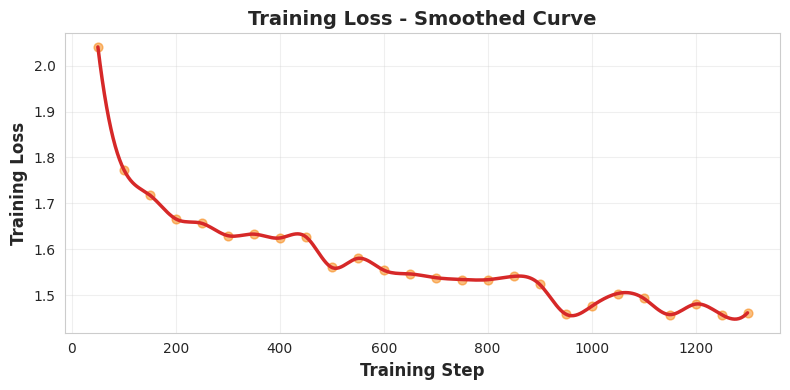

In [8]:
plt.figure(figsize=(8, 4))
x_smooth = np.linspace(min(steps), max(steps), 300)
spl = make_interp_spline(steps, loss, k=3)
y_smooth = spl(x_smooth)
plt.plot(x_smooth, y_smooth, linewidth=2.5, color='#D62828')
plt.scatter(steps, loss, s=40, alpha=0.5, color='#F77F00')
plt.xlabel('Training Step', fontsize=12, fontweight='bold')
plt.ylabel('Training Loss', fontsize=12, fontweight='bold')
plt.title('Training Loss - Smoothed Curve', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

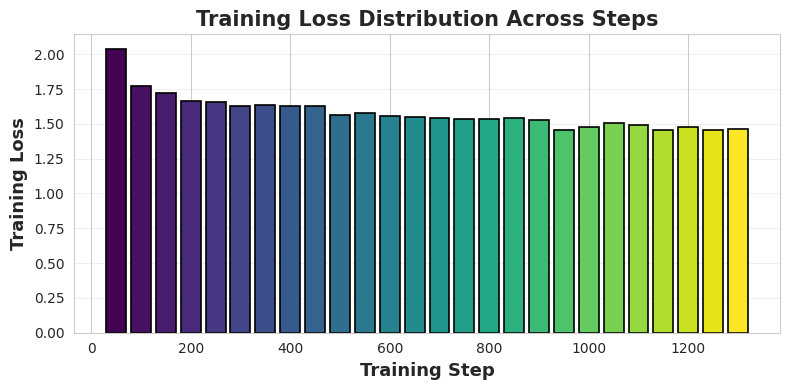

In [10]:
plt.figure(figsize=(8, 4))
colors = plt.cm.viridis(np.linspace(0, 1, len(steps)))
bars = plt.bar(steps, loss, width=40, color=colors, edgecolor='black', linewidth=1.2)
plt.xlabel('Training Step', fontsize=13, fontweight='bold')
plt.ylabel('Training Loss', fontsize=13, fontweight='bold')
plt.title('Training Loss Distribution Across Steps', fontsize=15, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Saving Adapters To Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!cp /content/lfm2_finetuned.zip /content/drive/MyDrive/

Mounted at /content/drive
